## L15: Clustering

Setup imports

In [13]:
!pip install pandas
!pip install matplotlib
!pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [14]:
from sklearn.datasets import make_blobs, load_digits
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import matplotlib.pyplot as plt
import pandas as pd

### Load data

In [15]:
centers = [[1, 1], [-1, -1], [1, -1]]

X, labels = make_blobs(n_samples=750, centers=centers, cluster_std=0.4, random_state=42)

X

array([[ 0.71263709, -0.64203025],
       [ 0.86291419,  0.67908909],
       [-0.37379039, -1.0263001 ],
       ...,
       [ 1.45712913,  1.30077321],
       [ 1.86127298,  0.69306097],
       [ 1.27278119,  0.8758933 ]], shape=(750, 2))

### Plot the blobs

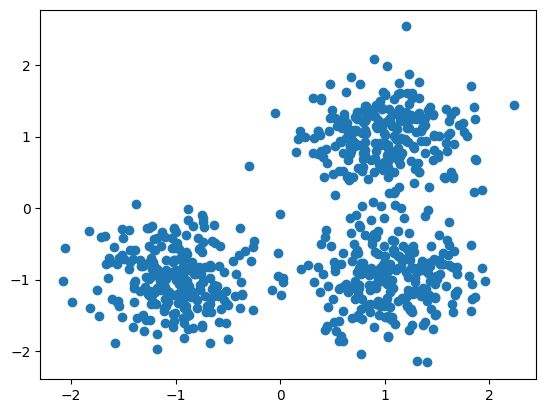

In [18]:
plt.scatter(X[:, 0], X[:, 1])

### Run k-means

In [ ]:
# Define the model
kmeans = KMeans(n_clusters=3)

# Run the model
kmeans.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [ ]:
# Look at labels from kmeans

kmeans.labels_

array([2, 0, 1, 1, 0, 0, 1, 2, 1, 1, 2, 0, 2, 0, 1, 0, 1, 0, 2, 0, 2, 0,
       0, 2, 0, 0, 1, 1, 1, 1, 0, 2, 0, 0, 1, 0, 0, 1, 2, 0, 0, 0, 2, 2,
       2, 1, 0, 2, 0, 0, 2, 1, 0, 1, 1, 0, 0, 0, 1, 0, 2, 1, 2, 2, 1, 0,
       2, 2, 0, 2, 1, 0, 2, 1, 2, 0, 2, 1, 2, 1, 0, 0, 1, 0, 0, 2, 0, 2,
       1, 0, 0, 2, 1, 2, 0, 0, 1, 1, 0, 2, 2, 0, 1, 1, 2, 1, 1, 0, 1, 1,
       2, 0, 1, 0, 1, 1, 0, 1, 2, 1, 0, 1, 2, 0, 2, 1, 1, 0, 1, 2, 1, 1,
       1, 0, 0, 0, 2, 0, 2, 1, 2, 0, 2, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 2,
       0, 2, 2, 2, 2, 1, 2, 0, 2, 2, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 2, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 2, 0, 2, 2, 0, 2, 1,
       1, 0, 2, 2, 0, 1, 2, 2, 1, 2, 1, 1, 0, 2, 2, 0, 0, 0, 0, 0, 1, 2,
       0, 1, 2, 0, 2, 2, 0, 0, 1, 1, 2, 0, 2, 2, 1, 1, 2, 2, 1, 2, 2, 1,
       0, 1, 1, 0, 1, 2, 2, 1, 1, 2, 1, 0, 2, 2, 0, 2, 0, 1, 2, 2, 2, 0,
       1, 0, 2, 1, 1, 1, 1, 2, 2, 2, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 2, 1,
       2, 2, 0, 0, 2, 0, 1, 1, 0, 2, 1, 0, 2, 1, 1,

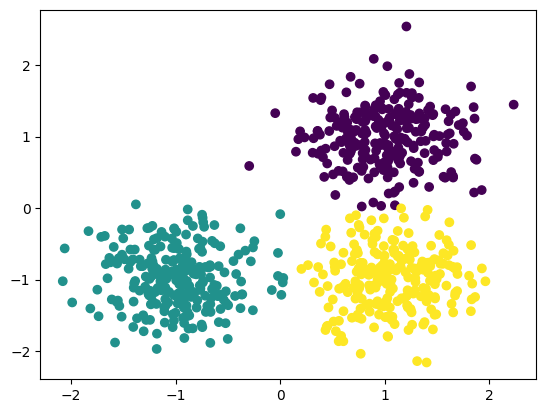

In [20]:
# Plot with colors from kmeans clustering
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_)

### Run DBScan

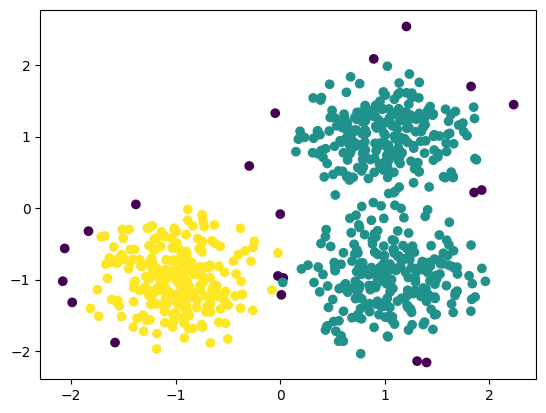

In [17]:
# Define the model
dbscan = DBSCAN(eps=0.3, min_samples=10)

# Run the model
dbscan.fit(X)

# Plot the results
plt.scatter(X[:, 0], X[:, 1], c=dbscan.labels_)

### Run agglomerative clustering

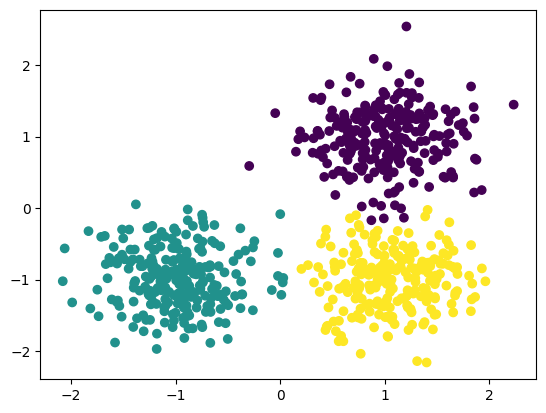

In [22]:
# Define the model
agg = AgglomerativeClustering(n_clusters=3)

# Run the model
agg.fit(X)

# Plot the result
plt.scatter(X[:, 0], X[:, 1], c=agg.labels_)

### Now apply clustering to the digits dataset

### Load data

In [23]:
digits = load_digits()


X = digits.data
y = digits.target

X

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64))

### Do dimension reduction for plotting

In [ ]:
lda = LDA(n_components=2) #Reduces dimensions and separates them into 2 columns

X_lda = lda.fit_transform(X, y)

X_lda

array([[-2.0146322 , -5.62348616],
       [ 0.2209674 ,  3.59240033],
       [ 2.23485453,  2.70950363],
       ...,
       [-1.04697178,  1.48367733],
       [ 0.40787292, -1.99167301],
       [ 0.17414501,  0.88717463]], shape=(1797, 2))

### Plot the dimension reduced data

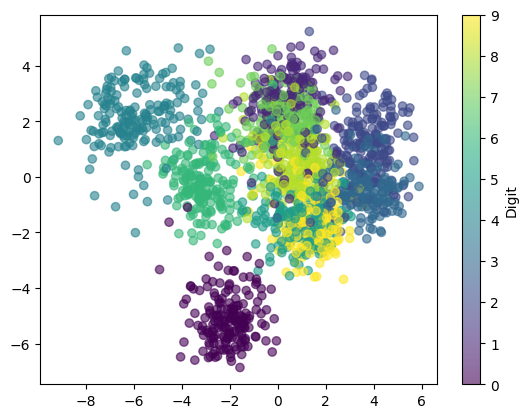

In [26]:
plt.scatter(X_lda[:, 0], X_lda[:, 1], c=y, alpha=0.6) # Alpha makes it transparent

plt.colorbar(label="Digit")

### Run k-means

In [27]:
# Define the model
kmeans = KMeans(n_clusters=10, random_state=42)

# Run the model
kmeans.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",10
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [29]:
# Evaluate the clustering

kmeans_score = adjusted_rand_score(y, kmeans.labels_) #The true labels are y, the predicted is kmeans.labels_

kmeans_score

0.725814218974996

### Activity 1
Apply DBSCAN and Agglomerative approaches to cluster the digits

Access accuracy using adjusted_rand_score

### Activity 2
Write loops to test different hyperparameters

Kmeans: n_clusters = [8, 10, 12]

DBSCAN: eps = [5, 10, 15, 25, 40]

Agglomerative: n_clusters = [8, 10, 12]

for each test, print the adjusted_rand_score

In [31]:
pd.DataFrame(X).head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,13.0,15.0,10.0,15.0,5.0,0.0,0.0,3.0,15.0,2.0,0.0,11.0,8.0,0.0,0.0,4.0,12.0,0.0,0.0,8.0,8.0,0.0,0.0,5.0,8.0,0.0,0.0,9.0,8.0,0.0,0.0,4.0,11.0,0.0,1.0,12.0,7.0,0.0,0.0,2.0,14.0,5.0,10.0,12.0,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,0.0,11.0,16.0,9.0,0.0,0.0,0.0,0.0,3.0,15.0,16.0,6.0,0.0,0.0,0.0,7.0,15.0,16.0,16.0,2.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,3.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,6.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,6.0,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,3.0,16.0,15.0,14.0,0.0,0.0,0.0,0.0,8.0,13.0,8.0,16.0,0.0,0.0,0.0,0.0,1.0,6.0,15.0,11.0,0.0,0.0,0.0,1.0,8.0,13.0,15.0,1.0,0.0,0.0,0.0,9.0,16.0,16.0,5.0,0.0,0.0,0.0,0.0,3.0,13.0,16.0,16.0,11.0,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,13.0,6.0,15.0,4.0,0.0,0.0,0.0,2.0,1.0,13.0,13.0,0.0,0.0,0.0,0.0,0.0,2.0,15.0,11.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,12.0,12.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,10.0,8.0,0.0,0.0,0.0,8.0,4.0,5.0,14.0,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,8.0,0.0,0.0,0.0,0.0,0.0,1.0,13.0,6.0,2.0,2.0,0.0,0.0,0.0,7.0,15.0,0.0,9.0,8.0,0.0,0.0,5.0,16.0,10.0,0.0,16.0,6.0,0.0,0.0,4.0,15.0,16.0,13.0,16.0,1.0,0.0,0.0,0.0,0.0,3.0,15.0,10.0,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


In [35]:
dbscan = DBSCAN(eps=25, min_samples=10) # We decided 25 since we see a range of 0 to 16 in the data
agg = AgglomerativeClustering(n_clusters=10)

dbscan.fit(X)
agg.fit(X)

dbscan_score = adjusted_rand_score(y, dbscan.labels_)
agg_score = adjusted_rand_score(y, agg.labels_)

print(dbscan_score)
print(agg_score)


0.1101692718899196
0.7940031835568753


### Run loop to test different values of n_clusters for k-means

In [40]:
num_cluster_list = [6, 8, 10, 11, 12, 14, 16, 18] # 11 is the highest

for num in num_cluster_list:
    kmeans = KMeans(n_clusters=num, random_state=42)

    kmeans.fit(X)

    score = adjusted_rand_score(y, kmeans.labels_)

    print(num, score)

6 0.43274246730070837
8 0.5780833208889035
10 0.725814218974996
11 0.7302511013991662
12 0.713453899006329
14 0.6776214333456351
16 0.6408546590243714
18 0.6487544719928953
